In [19]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

keras.utils.set_random_seed(42)

In [20]:
def plot_loss_curves(history):
  plt.clf()
  history_dict = history.history
  loss_values = history_dict["loss"]
  val_loss_values = history_dict["val_loss"]
  epochs = range(1, len(loss_values) + 1)
  plt.plot(epochs, loss_values, "bo", label="Training loss")
  plt.plot(epochs, val_loss_values, "b", label="Validation loss")
  plt.title("Training and validation loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

def plot_acc_curves(history):
  plt.clf()
  history_dict = history.history
  acc = history_dict["accuracy"]
  val_acc = history_dict["val_accuracy"]
  epochs = range(1, len(acc) + 1)
  plt.plot(epochs, acc, "bo", label="Training acc")
  plt.plot(epochs, val_acc, "b", label="Validation acc")
  plt.title("Training and validation accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

In [21]:
# Read data from URL

train_url = "https://www.dropbox.com/scl/fi/ito6bnl2yaf1uw0uqibzf/lyric_genre_train.csv?rlkey=04dkn5un2djza8x0bdmfnlw3u&st=y47qh8i4&dl=1"
val_url = "https://www.dropbox.com/scl/fi/xmywjzqsaa8n5sn1bs0t9/lyric_genre_val.csv?rlkey=hggbeo0s1iaxjpa6z80429xl9&st=6i7d8eau&dl=1"
test_url = "https://www.dropbox.com/scl/fi/fnocl69w9ojs9s5zb0xvf/lyric_genre_test.csv?rlkey=z4hjopw7vaihoh948cbb5mvdp&st=xwond7dp&dl=1"

train_df = pd.read_csv(train_url,index_col=0)
val_df = pd.read_csv(val_url,index_col=0)
test_df = pd.read_csv(test_url,index_col=0)


print(f"""
Train samples: {train_df.shape[0]}
Validation samples: {val_df.shape[0]}
Test samples: {test_df.shape[0]}
""")


Train samples: 48991
Validation samples: 16331
Test samples: 21774



In [22]:
# Let's one-hot-encode the target
y_train = pd.get_dummies(train_df['Genre']).to_numpy()
y_val = pd.get_dummies(val_df['Genre']).to_numpy()
y_test = pd.get_dummies(test_df['Genre']).to_numpy()

In [23]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2026-04-30 16:54:30--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-04-30 16:54:30--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-04-30 16:54:30--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.1’

gl

OSError: [Errno 5] Input/output error

In [24]:
!unzip -q glove.6B.zip glove.6B.100d.txt

replace glove.6B.100d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

OSError: [Errno 5] Input/output error

In [25]:
! head -1 glove.6B.100d.txt

the -0.038194 -0.24487 0.72812 -0.39961 0.083172 0.043953 -0.39141 0.3344 -0.57545 0.087459 0.28787 -0.06731 0.30906 -0.26384 -0.13231 -0.20757 0.33395 -0.33848 -0.31743 -0.48336 0.1464 -0.37304 0.34577 0.052041 0.44946 -0.46971 0.02628 -0.54155 -0.15518 -0.14107 -0.039722 0.28277 0.14393 0.23464 -0.31021 0.086173 0.20397 0.52624 0.17164 -0.082378 -0.71787 -0.41531 0.20335 -0.12763 0.41367 0.55187 0.57908 -0.33477 -0.36559 -0.54857 -0.062892 0.26584 0.30205 0.99775 -0.80481 -3.0243 0.01254 -0.36942 2.2167 0.72201 -0.24978 0.92136 0.034514 0.46745 1.1079 -0.19358 -0.074575 0.23353 -0.052062 -0.22044 0.057162 -0.15806 -0.30798 -0.41625 0.37972 0.15006 -0.53212 -0.2055 -1.2526 0.071624 0.70565 0.49744 -0.42063 0.26148 -1.538 -0.30223 -0.073438 -0.28312 0.37104 -0.25217 0.016215 -0.017099 -0.38984 0.87424 -0.72569 -0.51058 -0.52028 -0.1459 0.8278 0.27062


In [26]:
embedding_dim = 100
path_to_glove_file = f"glove.6B.{embedding_dim}d.txt"

embeddings_index = {}
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors.")

Found 400000 word vectors.


In [27]:
embeddings_index["movie"]

array([ 0.38251  ,  0.14821  ,  0.60601  , -0.51533  ,  0.43992  ,
        0.061053 , -0.62716  , -0.025385 ,  0.1643   , -0.22101  ,
        0.14423  , -0.37213  , -0.21683  , -0.08895  ,  0.097904 ,
        0.6561   ,  0.64455  ,  0.47698  ,  0.83849  ,  1.6486   ,
        0.88922  , -0.1181   , -0.012465 , -0.52082  ,  0.77854  ,
        0.48723  , -0.014991 , -0.14127  , -0.34747  , -0.29595  ,
        0.1028   ,  0.57191  , -0.045594 ,  0.026443 ,  0.53816  ,
        0.32257  ,  0.40788  , -0.043599 , -0.146    , -0.48346  ,
        0.32036  ,  0.55086  , -0.76259  ,  0.43269  ,  0.61753  ,
       -0.36503  , -0.60599  , -0.79615  ,  0.3929   , -0.23668  ,
       -0.34719  , -0.61201  ,  0.54747  ,  0.94812  ,  0.20941  ,
       -2.7771   , -0.6022   ,  0.8495   ,  1.2549   ,  0.017893 ,
       -0.041901 ,  2.1147   , -0.026618 , -0.28104  ,  0.68124  ,
       -0.14165  ,  0.99249  ,  0.49879  , -0.67538  ,  0.6417   ,
        0.42303  , -0.27913  ,  0.063403 ,  0.68909  , -0.3618

In [28]:
embeddings_index["film"]

array([ 0.19916 , -0.049702,  0.24579 , -0.32281 ,  0.89768 , -0.1278  ,
       -0.49506 ,  0.20814 , -0.20046 , -0.20604 ,  0.038292, -0.67277 ,
       -0.12689 , -0.18766 , -0.10277 ,  0.73128 ,  0.82408 ,  0.087288,
        0.69255 ,  1.3107  ,  0.49113 , -0.38097 ,  0.24338 , -0.27813 ,
        0.62506 ,  0.35978 ,  0.42041 , -0.24529 ,  0.14861 , -0.26726 ,
       -0.56262 ,  0.63843 , -0.54153 ,  0.36537 ,  0.20545 , -0.16604 ,
        0.72434 ,  0.29961 , -0.42501 , -0.35932 , -0.089288,  0.48752 ,
       -1.0927  ,  0.88818 ,  0.89941 , -0.7541  , -0.35492 , -0.76396 ,
        0.27468 ,  0.2757  , -0.48152 , -0.41399 ,  0.64489 ,  1.148   ,
       -0.29131 , -2.9387  , -0.83162 ,  0.95586 ,  1.1623  , -0.42502 ,
        0.15486 ,  2.2326  , -0.31339 , -0.030228,  0.79802 , -0.41302 ,
        0.72885 ,  0.7296  , -0.31909 ,  0.8956  ,  0.34625 ,  0.2923  ,
        0.40056 ,  0.78985 , -0.43999 ,  0.24698 , -0.46548 ,  0.055886,
       -0.62603 , -0.036487, -0.65429 ,  0.10563 , 

In [29]:
max_length = 300 #90% of songs
max_tokens = 5000

text_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=max_length,
)

In [30]:
text_vectorization.adapt(train_df.Lyric)

In [31]:
text_vectorization.get_vocabulary()[:10]

['', '[UNK]', 'the', 'you', 'i', 'to', 'and', 'a', 'me', 'it']

In [32]:
text_vectorization(["HODL, you are the best!"])

<tf.Tensor: shape=(1, 300), dtype=int64, numpy=
array([[  1,   3,  58,   2, 258,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
   

In [33]:
X_train = text_vectorization(train_df['Lyric'])
X_val = text_vectorization(val_df['Lyric'])
X_test = text_vectorization(test_df['Lyric'])

In [46]:
X_train.shape

TensorShape([48991, 300])

In [34]:
vocabulary = text_vectorization.get_vocabulary()
word_index = dict(zip(vocabulary, range(len(vocabulary))))

counter = 0
embedding_matrix = np.zeros((max_tokens, embedding_dim))
for word, i in word_index.items():
    if i < max_tokens:
        embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
    else:
        counter += 1

In [ ]:
embedding_layer = keras.layers.Embedding(
    max_tokens, 
    embedding_dim,
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    trainable=False,
    mask_zero=True,
    name="Embedding")

In [47]:
input = keras.Input(shape=(max_length,), name="input")
embedded = embedding_layer(input)
embedded = keras.layers.GlobalAveragePooling1D()(embedded)

x = keras.layers.Dense(8, activation="relu")(embedded)
output = keras.layers.Dense(3, activation="softmax")(x)
model = keras.Model(input, output)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 300)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 100)  │    500,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 300)       │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ embedding[3][0],  │
│ (GlobalAveragePool… │                   │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 8)         │        808 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 3)         │         27 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 500,835 (1.91 MB)

 Trainable params: 835 (3.26 KB)

 Non-trainable params: 500,000 (1.91 MB)

In [48]:
emb = model.layers[1]
emb.weights

[<Variable path=embedding/embeddings, shape=(5000, 100), dtype=float32, value=[[ 0.        0.        0.       ...  0.        0.        0.      ]
  [ 0.        0.        0.       ...  0.        0.        0.      ]
  [-0.038194 -0.24487   0.72812  ... -0.1459    0.8278    0.27062 ]
  ...
  [ 0.33947   0.16186   0.083984 ... -0.66934  -0.073064  0.91467 ]
  [-0.09169   0.10361   0.23232  ... -0.13697  -0.81738   0.3868  ]
  [ 0.28468  -0.26489   0.1649   ... -0.6158   -0.10085   1.0357  ]]>]

In [51]:
model.compile(optimizer="adam", 
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [54]:
history = model.fit(X_train, y_train, 
          validation_data=(X_val, y_val),
          batch_size=32,
          epochs=10)

Epoch 1/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6222 - loss: 0.8050 - val_accuracy: 0.6239 - val_loss: 0.8022
Epoch 2/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6230 - loss: 0.8040 - val_accuracy: 0.6253 - val_loss: 0.8012
Epoch 3/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6239 - loss: 0.8031 - val_accuracy: 0.6261 - val_loss: 0.8006
Epoch 4/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6246 - loss: 0.8022 - val_accuracy: 0.6270 - val_loss: 0.8004
Epoch 5/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6254 - loss: 0.8014 - val_accuracy: 0.6284 - val_loss: 0.7995
Epoch 6/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6263 - loss: 0.8008 - val_accuracy: 0.6279 - val_loss: 0.7990
Epoch 7/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6267 - loss: 0.8002 - val_accuracy: 0.6287 - val_loss: 0.7985
Epoch 8/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6278 - 

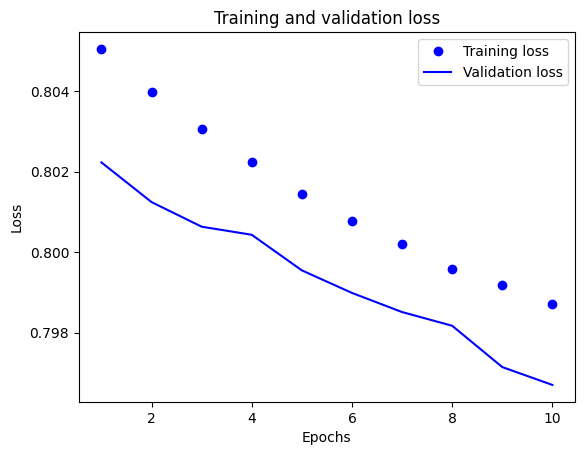

In [55]:
plot_loss_curves(history)

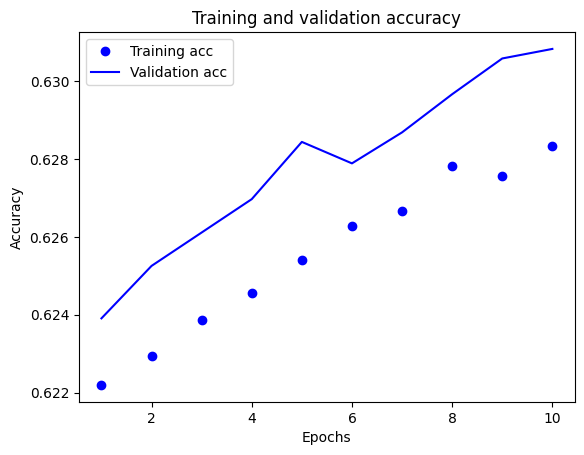

In [56]:
plot_acc_curves(history)

In [57]:
model.evaluate(X_test, y_test)

681/681 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6250 - loss: 0.8088


[0.8087940216064453, 0.6250115036964417]

## Part 2: lets fine-tune glove embeddings as well

In [58]:
embedding_layer = keras.layers.Embedding(
    max_tokens, 
    embedding_dim,
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    trainable=True,
    mask_zero=True,
    name="Embedding")

input = keras.Input(shape=(max_length,), name="input")
embedded = embedding_layer(input)
embedded = keras.layers.GlobalAveragePooling1D()(embedded)

x = keras.layers.Dense(8, activation="relu")(embedded)
output = keras.layers.Dense(3, activation="softmax")(x)
model = keras.Model(input, output)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 300)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding           │ (None, 300, 100)  │    500,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 300)       │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ Embedding[0][0],  │
│ (GlobalAveragePool… │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 8)         │        808 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 3)         │         27 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 500,835 (1.91 MB)

 Trainable params: 500,835 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
model.layers[1].get_weights()

[array([[ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
          0.      ],
        [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
          0.      ],
        [-0.038194, -0.24487 ,  0.72812 , ..., -0.1459  ,  0.8278  ,
          0.27062 ],
        ...,
        [ 0.33947 ,  0.16186 ,  0.083984, ..., -0.66934 , -0.073064,
          0.91467 ],
        [-0.09169 ,  0.10361 ,  0.23232 , ..., -0.13697 , -0.81738 ,
          0.3868  ],
        [ 0.28468 , -0.26489 ,  0.1649  , ..., -0.6158  , -0.10085 ,
          1.0357  ]], dtype=float32)]

In [62]:
model.compile(optimizer="adam", 
              loss="categorical_crossentropy",
              metrics=["accuracy"])
history = model.fit(X_train, y_train, 
          validation_data=(X_val, y_val),
          batch_size=32,
          epochs=10)

Epoch 1/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.6560 - loss: 0.7474 - val_accuracy: 0.7076 - val_loss: 0.6611
Epoch 2/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7188 - loss: 0.6362 - val_accuracy: 0.7135 - val_loss: 0.6442
Epoch 3/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7314 - loss: 0.6064 - val_accuracy: 0.7158 - val_loss: 0.6417
Epoch 4/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.7397 - loss: 0.5886 - val_accuracy: 0.7167 - val_loss: 0.6439
Epoch 5/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7451 - loss: 0.5765 - val_accuracy: 0.7160 - val_loss: 0.6477
Epoch 6/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.7494 - loss: 0.5673 - val_accuracy: 0.7153 - val_loss: 0.6519
Epoch 7/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7529 - loss: 0.5603 - val_accuracy: 0.7136 - val_loss: 0.6557
Epoch 8/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7565 -

In [63]:
model.layers[1].get_weights()

[array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.2511264 , -0.41646352, -1.2766485 , ..., -1.2899054 ,
          0.3754224 ,  1.1420519 ],
        [-0.2722248 , -0.4424267 ,  1.0888041 , ...,  1.4492763 ,
          0.6015515 , -0.6592306 ],
        ...,
        [ 0.31602827, -0.44373274, -0.33511937, ..., -0.1851671 ,
          0.66476953,  0.53529483],
        [-0.9485163 , -0.62338936,  1.0996673 , ...,  0.45859477,
         -1.201958  , -0.38603055],
        [-0.22270589, -0.5462493 ,  1.4725139 , ...,  0.31916112,
         -0.92153835,  0.5252056 ]], dtype=float32)]

In [64]:
model.evaluate(X_test, y_test)

681/681 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7132 - loss: 0.6798


[0.6798047423362732, 0.7132359743118286]

## Part 3: Custom embeddings

In [65]:
embedding_layer = keras.layers.Embedding(
    max_tokens, 
    embedding_dim,
    trainable=True,
    mask_zero=True,
    name="Embedding")

input = keras.Input(shape=(max_length,), name="input")
embedded = embedding_layer(input)
embedded = keras.layers.GlobalAveragePooling1D()(embedded)

x = keras.layers.Dense(8, activation="relu")(embedded)
output = keras.layers.Dense(3, activation="softmax")(x)
model = keras.Model(input, output)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 300)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding           │ (None, 300, 100)  │    500,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_5         │ (None, 300)       │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ Embedding[0][0],  │
│ (GlobalAveragePool… │                   │            │ not_equal_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 8)         │        808 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 3)         │         27 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 500,835 (1.91 MB)

 Trainable params: 500,835 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model.layers[1].get_weights()

[array([[-0.04813986, -0.00912187, -0.00984123, ..., -0.03533383,
          0.04807575,  0.01979636],
        [ 0.01069852,  0.01517744,  0.02828358, ..., -0.01639647,
         -0.01392116,  0.04819807],
        [ 0.03484476, -0.02444556,  0.00404234, ..., -0.03852354,
          0.02911899,  0.0214243 ],
        ...,
        [-0.02903971,  0.04042676,  0.00989424, ...,  0.00736462,
         -0.04738269,  0.03608819],
        [-0.03647863,  0.02029686, -0.00647783, ..., -0.0207979 ,
         -0.01889614,  0.01907494],
        [ 0.03591608, -0.03739961, -0.04873185, ...,  0.03146378,
          0.01642083, -0.02659758]], dtype=float32)]

In [67]:
model.compile(optimizer="adam", 
              loss="categorical_crossentropy",
              metrics=["accuracy"])
history = model.fit(X_train, y_train, 
          validation_data=(X_val, y_val),
          batch_size=32,
          epochs=10)

Epoch 1/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6690 - loss: 0.7260 - val_accuracy: 0.7128 - val_loss: 0.6503
Epoch 2/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7281 - loss: 0.6213 - val_accuracy: 0.7157 - val_loss: 0.6444
Epoch 3/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7388 - loss: 0.5953 - val_accuracy: 0.7103 - val_loss: 0.6501
Epoch 4/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7434 - loss: 0.5826 - val_accuracy: 0.7137 - val_loss: 0.6524
Epoch 5/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7495 - loss: 0.5725 - val_accuracy: 0.7168 - val_loss: 0.6542
Epoch 6/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7525 - loss: 0.5650 - val_accuracy: 0.7141 - val_loss: 0.6587
Epoch 7/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7570 - loss: 0.5604 - val_accuracy: 0.7110 - val_loss: 0.6664
Epoch 8/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7594 -

In [68]:
model.layers[1].get_weights()

[array([[-0.04813986, -0.00912187, -0.00984123, ..., -0.03533383,
          0.04807575,  0.01979636],
        [-2.3787637 ,  2.1569948 ,  2.372586  , ...,  0.8138699 ,
          2.2665374 ,  0.45269832],
        [ 1.607654  , -1.2668338 , -1.712612  , ..., -0.72286713,
         -1.8729222 , -1.5141689 ],
        ...,
        [-0.6740817 ,  0.5606302 ,  0.6917291 , ...,  0.3629696 ,
          0.8538654 , -0.14114954],
        [-0.9149614 ,  0.8996784 ,  0.8508515 , ...,  0.81931335,
          0.6930252 ,  0.90607077],
        [-0.87182873,  1.5961608 ,  0.84581345, ...,  0.610035  ,
          0.83980966,  0.7672599 ]], dtype=float32)]

In [69]:
model.evaluate(X_test, y_test)

681/681 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6945 - loss: 0.7009


[0.7009287476539612, 0.6945439577102661]